# Blending Predictions

Blending is the process of combining predictions from multiple models into a single final prediction.

Ensembling (broad)

├── Blending          ← weighted average of predictions

├── Stacking          ← model trained on top of other models' predictions  

├── Bagging           ← what Random Forest does internally

└── Boosting          ← what LightGBM/XGBoost does internally

In [1]:
import numpy as np
import pandas as pd
import json, os, glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

import sys
print(sys.executable)

# ── Load ground truth ─────────────────────────────────────────
Y_train = pd.read_csv('../data/processed/Y_train.csv').squeeze()
test    = pd.read_csv('../data/raw/test.csv')

# ── Load OOF predictions ──────────────────────────────────────
oof_xgb   = np.load('../data/output/oof/oof_round7_xgb_fe_linear.npy')
oof_lgbm  = np.load('../data/output/oof/oof_round6_lightGBM_fe_linear-200.npy')
oof_lasso = np.load('../data/output/oof/oof_round5_linreg_lasso_fe-linear.npy')

# ── Load test predictions (already in price space) ───────────
test_xgb   = pd.read_csv('../data/output/round7_xgb_fe_linear.csv')['SalePrice']
test_lgbm  = pd.read_csv('../data/output/round6_lightGBM_fe_linear-200.csv')['SalePrice']
test_lasso = pd.read_csv('../data/output/round5_linreg_lasso_fe-linear.csv')['SalePrice']

# ── Convert test preds to log space to match OOF ─────────────
test_xgb_log   = np.log1p(test_xgb)
test_lgbm_log  = np.log1p(test_lgbm)
test_lasso_log = np.log1p(test_lasso)

# ── Baselines ─────────────────────────────────────────────────
print("── Individual OOF Baselines ──")
baselines = {
    'xgb'  : root_mean_squared_error(Y_train, oof_xgb),
    'lgbm' : root_mean_squared_error(Y_train, oof_lgbm),
    'lasso': root_mean_squared_error(Y_train, oof_lasso),
}
for name, rmse in baselines.items():
    print(f"  {name:<8} {rmse:.5f}")

c:\Users\Chyi\anaconda3\envs\kaggle\python.exe
── Individual OOF Baselines ──
  xgb      0.12630
  lgbm     0.13188
  lasso    0.13932


── OOF Prediction Correlation ──
          xgb    lgbm   lasso
xgb    1.0000  0.9938  0.9809
lgbm   0.9938  1.0000  0.9778
lasso  0.9809  0.9778  1.0000


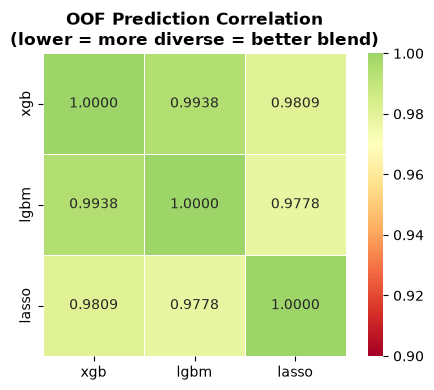


💡 Insight:
  XGB  vs LGBM  correlation: 0.9938
  XGB  vs Lasso correlation: 0.9809
  LGBM vs Lasso correlation: 0.9778

  Lower correlation = more diverse = better blend candidate


In [2]:
oof_df = pd.DataFrame({
    'xgb'  : oof_xgb,
    'lgbm' : oof_lgbm,
    'lasso': oof_lasso,
})

corr = oof_df.corr()

print("── OOF Prediction Correlation ──")
print(corr.round(4).to_string())

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    center=0.97,
    square=True,
    vmin=0.90,
    vmax=1.00,
    linewidths=0.5
)
plt.title('OOF Prediction Correlation\n(lower = more diverse = better blend)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/oof_correlation.png', dpi=150)
plt.show()

# ── Key insight ───────────────────────────────────────────────
print("\n💡 Insight:")
print(f"  XGB  vs LGBM  correlation: {corr.loc['xgb',  'lgbm']:.4f}")
print(f"  XGB  vs Lasso correlation: {corr.loc['xgb',  'lasso']:.4f}")
print(f"  LGBM vs Lasso correlation: {corr.loc['lgbm', 'lasso']:.4f}")
print(f"\n  Lower correlation = more diverse = better blend candidate")

## Type 1: Simple Average

In [3]:
oof_simple = (oof_xgb + oof_lgbm + oof_lasso) / 3
rmse_simple = root_mean_squared_error(Y_train, oof_simple)
print(f"Simple Average OOF RMSE: {rmse_simple:.5f}")

test_simple = np.expm1(
    (test_xgb_log + test_lgbm_log + test_lasso_log) / 3
)

Simple Average OOF RMSE: 0.12674


## Type 2 — Weighted Average (CV-Score Based)

In [4]:
# Weight inversely proportional to OOF RMSE
# Better model (lower RMSE) gets higher weight
total    = sum(1/v for v in baselines.values())
weights  = {k: (1/v) / total for k, v in baselines.items()}

print("── Inverse RMSE Weights ──")
for name, w in weights.items():
    print(f"  {name:<8} {w:.4f}")

oof_weighted = (weights['xgb']   * oof_xgb  +
                weights['lgbm']  * oof_lgbm +
                weights['lasso'] * oof_lasso)

rmse_weighted = root_mean_squared_error(Y_train, oof_weighted)
print(f"\nWeighted Average OOF RMSE: {rmse_weighted:.5f}")

test_weighted = np.expm1(
    weights['xgb']   * test_xgb_log  +
    weights['lgbm']  * test_lgbm_log +
    weights['lasso'] * test_lasso_log
)

── Inverse RMSE Weights ──
  xgb      0.3491
  lgbm     0.3344
  lasso    0.3165

Weighted Average OOF RMSE: 0.12662


## Type 3 — Grid Search Optimised Weights

In [5]:
best_rmse    = np.inf
best_weights = None
grid_results = []

for w1 in np.arange(0.0, 1.01, 0.05):
    for w2 in np.arange(0.0, 1.01 - w1, 0.05):
        w3   = round(1.0 - w1 - w2, 4)
        if w3 < 0:
            continue

        oof_blend = w1 * oof_xgb + w2 * oof_lgbm + w3 * oof_lasso
        rmse      = root_mean_squared_error(Y_train, oof_blend)

        grid_results.append({
            'w_xgb'  : round(w1, 2),
            'w_lgbm' : round(w2, 2),
            'w_lasso': round(w3, 2),
            'rmse'   : rmse
        })

        if rmse < best_rmse:
            best_rmse    = rmse
            best_weights = (w1, w2, w3)

grid_df = pd.DataFrame(grid_results).sort_values('rmse')

print(f"── Grid Search Best Weights ──")
print(f"  XGB   = {best_weights[0]:.2f}")
print(f"  LGBM  = {best_weights[1]:.2f}")
print(f"  Lasso = {best_weights[2]:.2f}")
print(f"  RMSE  = {best_rmse:.5f}")
print(f"\nTop 5 weight combos:")
print(grid_df.head().to_string(index=False))

test_optimised = np.expm1(
    best_weights[0] * test_xgb_log  +
    best_weights[1] * test_lgbm_log +
    best_weights[2] * test_lasso_log
)

── Grid Search Best Weights ──
  XGB   = 0.75
  LGBM  = 0.05
  Lasso = 0.20
  RMSE  = 0.12553

Top 5 weight combos:
 w_xgb  w_lgbm  w_lasso     rmse
  0.75    0.05     0.20 0.125531
  0.80    0.05     0.15 0.125546
  0.80    0.00     0.20 0.125549
  0.70    0.10     0.20 0.125550
  0.75    0.10     0.15 0.125555


## Type 4 — Stacking (Ridge Meta-Model)

In [6]:
# ── Build meta features ───────────────────────────────────────
meta_train = np.column_stack([oof_xgb,        oof_lgbm,       oof_lasso])
meta_test  = np.column_stack([test_xgb_log,   test_lgbm_log,  test_lasso_log])

print(f"Meta train : {meta_train.shape}")
print(f"Meta test  : {meta_test.shape}")

# ── Evaluate with KFold ───────────────────────────────────────
meta_model  = Ridge(alpha=1.0)
kf          = KFold(n_splits=5, shuffle=True, random_state=42)
meta_oof    = np.zeros(len(Y_train))

for fold, (tr_idx, val_idx) in enumerate(kf.split(meta_train)):
    meta_model.fit(meta_train[tr_idx], Y_train.iloc[tr_idx])
    meta_oof[val_idx] = meta_model.predict(meta_train[val_idx])
    fold_rmse = root_mean_squared_error(Y_train.iloc[val_idx], meta_oof[val_idx])
    print(f"  Fold {fold+1} RMSE: {fold_rmse:.5f}")

rmse_stack = root_mean_squared_error(Y_train, meta_oof)
print(f"\n✅ Stacking OOF RMSE: {rmse_stack:.5f}")

# ── Fit on full data and predict ──────────────────────────────
meta_model.fit(meta_train, Y_train)
test_stack = np.expm1(meta_model.predict(meta_test))

print(f"\n── Meta Model Coefficients ──")
print(f"  XGB   : {meta_model.coef_[0]:.4f}")
print(f"  LGBM  : {meta_model.coef_[1]:.4f}")
print(f"  Lasso : {meta_model.coef_[2]:.4f}")

Meta train : (1460, 3)
Meta test  : (1459, 3)
  Fold 1 RMSE: 0.12721
  Fold 2 RMSE: 0.11583
  Fold 3 RMSE: 0.16535
  Fold 4 RMSE: 0.11413
  Fold 5 RMSE: 0.10621

✅ Stacking OOF RMSE: 0.12747

── Meta Model Coefficients ──
  XGB   : 0.5888
  LGBM  : 0.1953
  Lasso : 0.2158


In [ ]:
os.makedirs('../data/output', exist_ok=True)

ensembles = {
    'round8_ensemble_simple'   : test_simple,
    'round8_ensemble_weighted' : test_weighted,
    'round8_ensemble_optimised': test_optimised,
    'round8_ensemble_stacking' : test_stack,
}

for filename, preds in ensembles.items():
    submission = pd.DataFrame({
        'Id'       : test['Id'],
        'SalePrice': preds
    })
    submission.to_csv(f'../data/output/{filename}.csv', index=False)
    print(f"✅ Saved: {filename}.csv")

✅ Saved: round8_ensemble_simple.csv
✅ Saved: round8_ensemble_weighted.csv
✅ Saved: round8_ensemble_optimised.csv
✅ Saved: round8_ensemble_stacking.csv


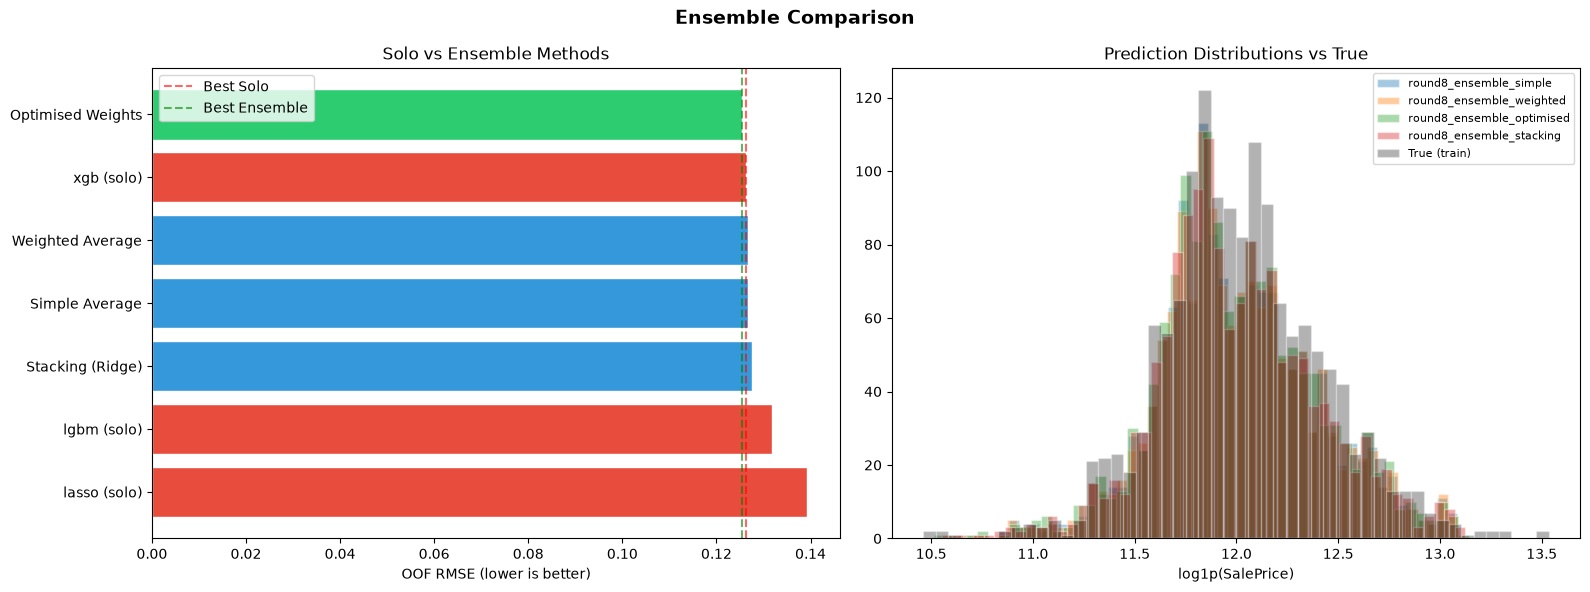


📋 FINAL ENSEMBLE LEADERBOARD
           Method  OOF RMSE
Optimised Weights  0.125531
       xgb (solo)  0.126298
 Weighted Average  0.126623
   Simple Average  0.126741
 Stacking (Ridge)  0.127472
      lgbm (solo)  0.131879
     lasso (solo)  0.139317


In [10]:
all_results = {
    # Baselines
    'xgb (solo)'          : baselines['xgb'],
    'lgbm (solo)'         : baselines['lgbm'],
    'lasso (solo)'        : baselines['lasso'],
    # Ensembles
    'Simple Average'      : rmse_simple,
    'Weighted Average'    : rmse_weighted,
    'Optimised Weights'   : best_rmse,
    'Stacking (Ridge)'    : rmse_stack,
}

results_df = pd.DataFrame(
    all_results.items(),
    columns=['Method', 'OOF RMSE']
).sort_values('OOF RMSE').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ensemble Comparison', fontsize=14, fontweight='bold')

# ── Bar chart ─────────────────────────────────────────────────
colors = []
for m in results_df['Method']:
    if m == results_df.iloc[0]['Method']:
        colors.append('#2ecc71')        # best   → green
    elif 'solo' in m:
        colors.append('#e74c3c')        # solo   → red
    else:
        colors.append('#3498db')        # blend  → blue

axes[0].barh(results_df['Method'], results_df['OOF RMSE'],
             color=colors, edgecolor='white')
axes[0].axvline(baselines['xgb'], color='red', linestyle='--',
                alpha=0.6, label='Best Solo')
axes[0].axvline(results_df['OOF RMSE'].min(), color='green', linestyle='--',
                alpha=0.6, label='Best Ensemble')
axes[0].set_xlabel('OOF RMSE (lower is better)')
axes[0].set_title('Solo vs Ensemble Methods')
axes[0].legend()
axes[0].invert_yaxis()

# ── Prediction distribution ───────────────────────────────────
for name, preds in ensembles.items():
    axes[1].hist(np.log1p(preds), bins=50, alpha=0.4,
                 label=name.replace('round10_ensemble_', ''),
                 edgecolor='white')

axes[1].hist(Y_train, bins=50, alpha=0.3, color='black',
             label='True (train)', edgecolor='white')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_title('Prediction Distributions vs True')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../plots/ensemble_comparison.png', dpi=150)
plt.show()

print("\n" + "=" * 45)
print("📋 FINAL ENSEMBLE LEADERBOARD")
print("=" * 45)
print(results_df.to_string(index=False))